In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('../data/Tweets.csv')

In [3]:
new_data = data.copy()

# Entrenamiento de BERT para Clasificación de Negative Reasons

Dado que el análisis de similitud léxica reveló solapamiento significativo entre categorías de queja, implementaremos un modelo BERT que puede capturar diferencias semánticas más sutiles entre los tweets.

BERT (Bidirectional Encoder Representations from Transformers) es especialmente adecuado para esta tarea porque:

1. **Comprensión contextual**: Puede entender el contexto completo de cada palabra en la oración
2. **Representaciones bidireccionales**: Considera tanto el contexto anterior como posterior
3. **Capacidad de fine-tuning**: Puede adaptarse específicamente a nuestro dominio de quejas de aerolíneas
4. **Manejo de sutilezas**: Puede distinguir entre categorías que comparten vocabulario similar

In [4]:

# Imports para BERT
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Importar imbalanced-learn
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
print("✅ Todas las librerías importadas correctamente")

# Verificar si CUDA está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
else:
    print("Usando CPU - el entrenamiento será más lento")

✅ Todas las librerías importadas correctamente
Usando dispositivo: cuda
GPU disponible: NVIDIA GeForce RTX 3060


## 1. Preparación de Datos para BERT

In [5]:
# Preparar los datos para BERT
# Filtrar tweets negativos con negativereason válido (sin "Can't Tell")
bert_df = new_data[(new_data['airline_sentiment'] == 'negative') & 
                   (new_data['negativereason'].notna())].copy()

# Remover "Can't Tell" si aún existe
bert_df = bert_df[bert_df['negativereason'] != "Can't Tell"]

print(f"Número total de tweets para entrenamiento: {len(bert_df)}")
print(f"Distribución de clases:")
print(bert_df['negativereason'].value_counts())

# Verificar que no tengamos clases con muy pocos ejemplos
min_samples = bert_df['negativereason'].value_counts().min()
print(f"\nClase con menos ejemplos: {min_samples}")

# Codificar las etiquetas
label_encoder = LabelEncoder()
bert_df['labels'] = label_encoder.fit_transform(bert_df['negativereason'])

# Crear mapeo de etiquetas
label_to_id = {label: idx for idx, label in enumerate(label_encoder.classes_)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

print(f"\nMapeo de etiquetas:")
for label, idx in label_to_id.items():
    print(f"  {idx}: {label}")

# Usar el texto original (sin procesar) para BERT
bert_df['text_clean'] = bert_df['text'].str.replace(r'http\S+', '', regex=True)  # Solo remover URLs
bert_df['text_clean'] = bert_df['text_clean'].str.replace(r'@\w+', '@user', regex=True)  # Reemplazar mentions

print(f"\nPrimeros 5 ejemplos de texto limpio:")
for i, (text, label) in enumerate(zip(bert_df['text_clean'].head(), bert_df['negativereason'].head())):
    print(f"{i+1}. [{label}] {text[:100]}...")

Número total de tweets para entrenamiento: 7988
Distribución de clases:
negativereason
Customer Service Issue         2910
Late Flight                    1665
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64

Clase con menos ejemplos: 74

Mapeo de etiquetas:
  0: Bad Flight
  1: Cancelled Flight
  2: Customer Service Issue
  3: Damaged Luggage
  4: Flight Attendant Complaints
  5: Flight Booking Problems
  6: Late Flight
  7: Lost Luggage
  8: longlines

Primeros 5 ejemplos de texto limpio:
1. [Bad Flight] @user it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they hav...
2. [Late Flight] @user SFO-PDX schedule is still MIA....
3. [Bad Flight] @user  I flew from NYC to SFO last week and couldn't fully sit in my seat due to t

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression


📊 Distribución ANTES del oversampling:
Entrenamiento: Counter({2: 1863, 6: 1066, 1: 542, 7: 463, 0: 371, 5: 338, 4: 308, 8: 114, 3: 47})
Validación: Counter({2: 465, 6: 266, 1: 136, 7: 116, 0: 93, 5: 85, 4: 77, 8: 28, 3: 12})

📊 Distribución DESPUÉS del oversampling:
Entrenamiento: Counter({7: 1863, 4: 1863, 6: 1863, 2: 1863, 0: 1863, 5: 1863, 1: 1863, 8: 1863, 3: 1863})
Validación: Counter({2: 465, 6: 266, 1: 136, 7: 116, 0: 93, 5: 85, 4: 77, 8: 28, 3: 12}) (sin cambios)

Tamaño original de entrenamiento: 5112
Tamaño después del oversampling: 16767
Incremento: 11655 muestras adicionales
Tamaño del conjunto de entrenamiento: 16767
Tamaño del conjunto de validación: 1278
Tamaño del conjunto de prueba: 1598

Distribución en entrenamiento (después del oversampling):
  Bad Flight: 1863
  Cancelled Flight: 1863
  Customer Service Issue: 1863
  Damaged Luggage: 1863
  Flight Attendant Complaints: 1863
  Flight Booking Problems: 1863
  Late Flight: 1863
  Lost Luggage: 1863
  longlines: 1863


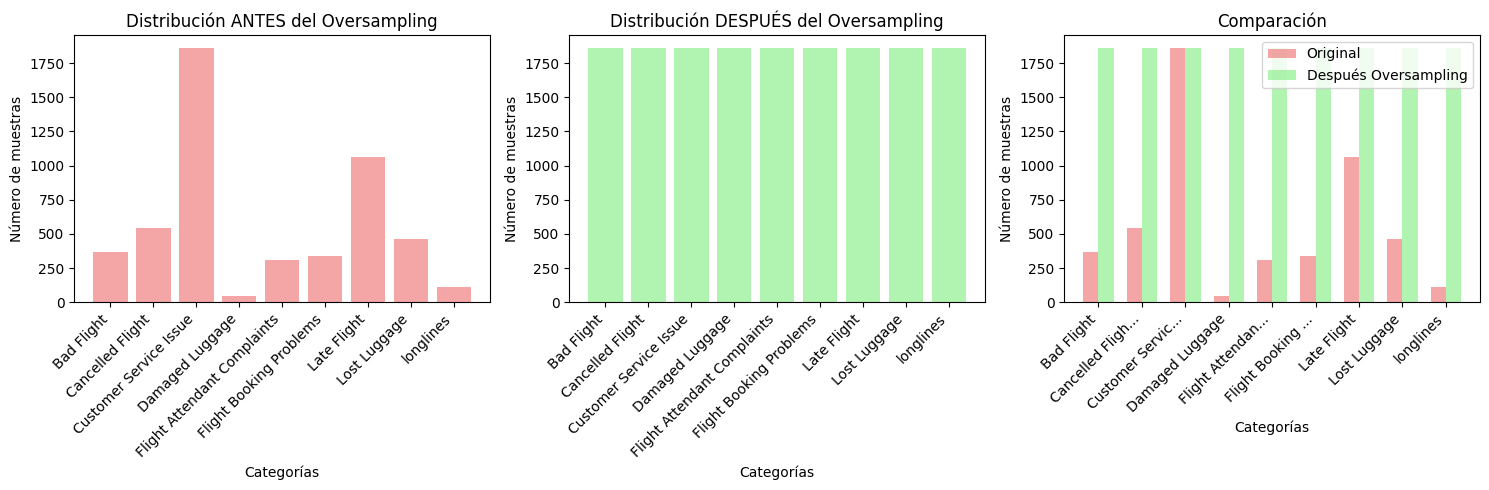

📊 Estadísticas del Oversampling:
Muestras originales: 5112
Muestras después del oversampling: 16767
Incremento: 11655 muestras (228.0%)
Muestras por clase después del oversampling: 1863 (todas iguales: True)


In [7]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    bert_df['text_clean'], 
    bert_df['labels'], 
    test_size=0.2, 
    random_state=42, 
    stratify=bert_df['labels']
)

# Crear un conjunto de validación del conjunto de entrenamiento
X_train, X_val, y_train, y_val = train_test_split(
    X_train, 
    y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train
)

# OVERSAMPLING para balancear las clases
print("📊 Distribución ANTES del oversampling:")
print(f"Entrenamiento: {Counter(y_train)}")
print(f"Validación: {Counter(y_val)}")

# Aplicar oversampling solo al conjunto de entrenamiento
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train.values.reshape(-1, 1), y_train
)

# Convertir de vuelta a formato original
X_train_resampled = pd.Series([text[0] for text in X_train_resampled])
y_train_resampled = pd.Series(y_train_resampled)

print("\n📊 Distribución DESPUÉS del oversampling:")
print(f"Entrenamiento: {Counter(y_train_resampled)}")
print(f"Validación: {Counter(y_val)} (sin cambios)")

print(f"\nTamaño original de entrenamiento: {len(X_train)}")
print(f"Tamaño después del oversampling: {len(X_train_resampled)}")
print(f"Incremento: {len(X_train_resampled) - len(X_train)} muestras adicionales")

print(f"Tamaño del conjunto de entrenamiento: {len(X_train_resampled)}")
print(f"Tamaño del conjunto de validación: {len(X_val)}")
print(f"Tamaño del conjunto de prueba: {len(X_test)}")

# Verificar distribución de clases
print(f"\nDistribución en entrenamiento (después del oversampling):")
train_counts = pd.Series(y_train_resampled).value_counts().sort_index()
for idx, count in train_counts.items():
    print(f"  {id_to_label[idx]}: {count}")

print(f"\nDistribución en validación:")
val_counts = pd.Series(y_val).value_counts().sort_index()
for idx, count in val_counts.items():
    print(f"  {id_to_label[idx]}: {count}")

print(f"\nDistribución en prueba:")
test_counts = pd.Series(y_test).value_counts().sort_index()
for idx, count in test_counts.items():
    print(f"  {id_to_label[idx]}: {count}")

# Visualizar el impacto del oversampling
plt.figure(figsize=(15, 5))

# Antes del oversampling
plt.subplot(1, 3, 1)
original_counts = pd.Series(y_train).value_counts().sort_index()
original_labels = [id_to_label[i] for i in original_counts.index]
plt.bar(original_labels, original_counts.values, color='lightcoral', alpha=0.7)
plt.title('Distribución ANTES del Oversampling')
plt.xlabel('Categorías')
plt.ylabel('Número de muestras')
plt.xticks(rotation=45, ha='right')

# Después del oversampling
plt.subplot(1, 3, 2)
resampled_counts = pd.Series(y_train_resampled).value_counts().sort_index()
resampled_labels = [id_to_label[i] for i in resampled_counts.index]
plt.bar(resampled_labels, resampled_counts.values, color='lightgreen', alpha=0.7)
plt.title('Distribución DESPUÉS del Oversampling')
plt.xlabel('Categorías')
plt.ylabel('Número de muestras')
plt.xticks(rotation=45, ha='right')

# Comparación
plt.subplot(1, 3, 3)
x = np.arange(len(original_labels))
width = 0.35
plt.bar(x - width/2, original_counts.values, width, label='Original', color='lightcoral', alpha=0.7)
plt.bar(x + width/2, resampled_counts.values, width, label='Después Oversampling', color='lightgreen', alpha=0.7)
plt.title('Comparación')
plt.xlabel('Categorías')
plt.ylabel('Número de muestras')
plt.xticks(x, [label[:15] + '...' if len(label) > 15 else label for label in original_labels], rotation=45, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

# Mostrar estadísticas del oversampling
print("📊 Estadísticas del Oversampling:")
print(f"Muestras originales: {len(y_train)}")
print(f"Muestras después del oversampling: {len(y_train_resampled)}")
print(f"Incremento: {len(y_train_resampled) - len(y_train)} muestras ({((len(y_train_resampled) - len(y_train)) / len(y_train) * 100):.1f}%)")

# Verificar que todas las clases tengan el mismo número de muestras
max_samples = resampled_counts.max()
min_samples = resampled_counts.min()
print(f"Muestras por clase después del oversampling: {max_samples} (todas iguales: {max_samples == min_samples})")

## 2. Configuración del Tokenizador y Modelo BERT

In [8]:
# Configurar modelo BERT
model_name = "bert-base-uncased"  # Modelo base de BERT
num_labels = len(label_encoder.classes_)

print(f"Usando modelo: {model_name}")
print(f"Número de clases: {num_labels}")

# Inicializar tokenizador
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Función para tokenizar los datos
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding=False,  # Cambiar a False para usar padding dinámico
        max_length=128,  # Longitud máxima apropiada para tweets
        return_tensors=None  # Cambiar a None para evitar conflictos
    )

# Crear datasets (usando datos con oversampling para entrenamiento)
train_dataset = Dataset.from_dict({
    'text': X_train_resampled.tolist(),
    'labels': y_train_resampled.tolist()
})

val_dataset = Dataset.from_dict({
    'text': X_val.tolist(),
    'labels': y_val.tolist()
})

test_dataset = Dataset.from_dict({
    'text': X_test.tolist(),
    'labels': y_test.tolist()
})

# Tokenizar los datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# IMPORTANTE: Remover la columna 'text' después de tokenizar
train_dataset = train_dataset.remove_columns(['text'])
val_dataset = val_dataset.remove_columns(['text'])
test_dataset = test_dataset.remove_columns(['text'])

print("Datasets tokenizados exitosamente")
print(f"Columnas en train_dataset: {train_dataset.column_names}")
print(f"Ejemplo de tokenización:")
print(f"Input IDs shape: {len(train_dataset[0]['input_ids'])}")
print(f"Attention mask shape: {len(train_dataset[0]['attention_mask'])}")
print(f"Labels: {train_dataset[0]['labels']}")
print(f"Primeros 20 tokens: {tokenizer.convert_ids_to_tokens(train_dataset[0]['input_ids'])[:20]}")  # Primeros 20 tokens

Usando modelo: bert-base-uncased
Número de clases: 9


Map:   0%|          | 0/16767 [00:00<?, ? examples/s]

Map:   0%|          | 0/1278 [00:00<?, ? examples/s]

Map:   0%|          | 0/1598 [00:00<?, ? examples/s]

Datasets tokenizados exitosamente
Columnas en train_dataset: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Ejemplo de tokenización:
Input IDs shape: 32
Attention mask shape: 32
Labels: 7
Primeros 20 tokens: ['[CLS]', '@', 'user', 'fl', '##t', '460', '##9', 'landed', 'over', 'half', 'an', 'hour', 'ago', '.', 'not', 'a', 'single', 'bag', 'yet', 'on']


In [9]:
# Inicializar modelo BERT para clasificación
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    label2id=label_to_id,
    id2label=id_to_label
)

# Mover modelo al dispositivo apropiado
model.to(device)

print(f"Modelo inicializado con {num_labels} clases")
print(f"Modelo movido a: {device}")

# Configurar data collator para padding dinámico
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Función para calcular métricas
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Calcular métricas
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("Configuración completada")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modelo inicializado con 9 clases
Modelo movido a: cuda
Configuración completada


## 3. Configuración del Entrenamiento

In [ ]:
# Configurar argumentos de entrenamiento
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./bert_twitter_classifier',
    num_train_epochs=4,  #  Lo deje en 4 épocas
    per_device_train_batch_size=16,  # Batch size para entrenamiento
    per_device_eval_batch_size=16,   # Batch size para evaluación
    warmup_steps=500,                # Pasos de warmup
    weight_decay=0.01,               # Regularización
    logging_dir='./logs',            # Directorio para logs
    logging_steps=100,               # Frecuencia de logging
    eval_strategy="steps",           # Evaluar cada cierto número de steps
    eval_steps=300,                  # Evaluar más frecuentemente (cada 300 steps)
    save_strategy="steps",           # Guardar cada cierto número de steps
    save_steps=300,                  # Guardar más frecuentemente
    load_best_model_at_end=True,     # Cargar el mejor modelo al final
    metric_for_best_model="f1",      # Métrica para seleccionar el mejor modelo
    greater_is_better=True,          # F1 mayor es mejor
    save_total_limit=3,              # Mantener los 3 mejores checkpoints
    push_to_hub=False,               # No subir a Hugging Face Hub
    remove_unused_columns=False,     # Mantener columnas no utilizadas
    dataloader_pin_memory=False,     # Desactivar pin_memory para evitar problemas
    learning_rate=2e-5,              # Learning rate específico para BERT
    lr_scheduler_type="cosine",      # Scheduler cosine para mejor convergencia
    fp16=True,                       # Usar precisión mixta para eficiencia (si tienes GPU)
    gradient_checkpointing=True,     # Ahorrar memoria
    report_to="none",                # Desactivar wandb/tensorboard si no se necesita
)

print("Argumentos de entrenamiento configurados:")
print(f"- Épocas: {training_args.num_train_epochs}")
print(f"- Batch size entrenamiento: {training_args.per_device_train_batch_size}")
print(f"- Batch size evaluación: {training_args.per_device_eval_batch_size}")
print(f"- Learning rate: {training_args.learning_rate}")
print(f"- Warmup steps: {training_args.warmup_steps}")
print(f"- Weight decay: {training_args.weight_decay}")
print(f"- Directorio de salida: {training_args.output_dir}")

Argumentos de entrenamiento configurados:
- Épocas: 8
- Batch size entrenamiento: 16
- Batch size evaluación: 16
- Learning rate: 2e-05
- Warmup steps: 500
- Weight decay: 0.01
- Directorio de salida: ./bert_twitter_classifier


In [11]:
# Inicializar Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer inicializado exitosamente")
print(f"Número de parámetros del modelo: {sum(p.numel() for p in model.parameters()):,}")
print(f"Número de parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Verificar configuración antes del entrenamiento
print("\nResumen de configuración:")
print(f"- Modelo: {model_name}")
print(f"- Dispositivo: {device}")
print(f"- Clases: {num_labels}")
print(f"- Datos de entrenamiento: {len(train_dataset)}")
print(f"- Datos de validación: {len(val_dataset)}")
print(f"- Datos de prueba: {len(test_dataset)}")
print(f"- Máxima longitud de secuencia: 128")
print(f"- Epochs: {training_args.num_train_epochs}")
print(f"- Batch size: {training_args.per_device_train_batch_size}")
print(f"- Learning rate: {training_args.learning_rate}")

print("\n¡Listo para entrenar! Ejecuta la siguiente celda para comenzar el entrenamiento.")

Trainer inicializado exitosamente
Número de parámetros del modelo: 109,489,161
Número de parámetros entrenables: 109,489,161

Resumen de configuración:
- Modelo: bert-base-uncased
- Dispositivo: cuda
- Clases: 9
- Datos de entrenamiento: 16767
- Datos de validación: 1278
- Datos de prueba: 1598
- Máxima longitud de secuencia: 128
- Epochs: 8
- Batch size: 16
- Learning rate: 2e-05

¡Listo para entrenar! Ejecuta la siguiente celda para comenzar el entrenamiento.


## 4. Entrenamiento del Modelo

In [12]:
# Entrenar el modelo
print("🚀 Iniciando entrenamiento del modelo BERT...")
print("Este proceso puede tomar varios minutos dependiendo de tu hardware.")
print("Si estás usando CPU, puede tomar 30-60 minutos.")
print("Si estás usando GPU, puede tomar 10-20 minutos.")
print()

# Entrenar modelo
training_result = trainer.train()

print("✅ Entrenamiento completado!")
print(f"Loss final: {training_result.training_loss:.4f}")
print(f"Tiempo total: {training_result.metrics['train_runtime']:.2f} segundos")
print(f"Pasos por segundo: {training_result.metrics['train_samples_per_second']:.2f}")

# Guardar el modelo entrenado
trainer.save_model()
tokenizer.save_pretrained('./bert_twitter_classifier')

print("\n💾 Modelo guardado en './bert_twitter_classifier'")
print("El modelo y tokenizador están listos para usar.")

🚀 Iniciando entrenamiento del modelo BERT...
Este proceso puede tomar varios minutos dependiendo de tu hardware.
Si estás usando CPU, puede tomar 30-60 minutos.
Si estás usando GPU, puede tomar 10-20 minutos.



Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
300,1.846400,1.694548,0.480438,0.497520,0.583462,0.480438
600,0.923200,1.117770,0.636150,0.652213,0.710226,0.636150
900,0.537900,0.967430,0.694053,0.699415,0.713506,0.694053
1200,0.282700,1.093379,0.686228,0.694964,0.723578,0.686228
1500,0.263300,1.222492,0.669797,0.680969,0.712103,0.669797
1800,0.176700,1.208683,0.694836,0.695455,0.707034,0.694836
2100,0.145900,1.298721,0.700313,0.695482,0.703344,0.700313
2400,0.062400,1.625414,0.692488,0.687158,0.693537,0.692488
2700,0.128100,1.593319,0.702660,0.702760,0.712717,0.702660
3000,0.053500,1.628079,0.707355,0.704223,0.703047,0.707355


✅ Entrenamiento completado!
Loss final: 0.1970
Tiempo total: 1230.41 segundos
Pasos por segundo: 109.02

💾 Modelo guardado en './bert_twitter_classifier'
El modelo y tokenizador están listos para usar.

💾 Modelo guardado en './bert_twitter_classifier'
El modelo y tokenizador están listos para usar.


## 5. Evaluación del Modelo

🔍 Evaluando modelo en conjunto de prueba...



📊 Métricas del modelo BERT:
Accuracy: 0.6984
Precision (weighted): 0.6908
Recall (weighted): 0.6984
F1-score (weighted): 0.6914

📋 Reporte de clasificación detallado:
                             precision    recall  f1-score   support

                 Bad Flight       0.53      0.45      0.49       116
           Cancelled Flight       0.78      0.71      0.75       169
     Customer Service Issue       0.75      0.79      0.77       582
            Damaged Luggage       0.50      0.33      0.40        15
Flight Attendant Complaints       0.58      0.41      0.48        96
    Flight Booking Problems       0.51      0.52      0.52       106
                Late Flight       0.70      0.81      0.75       333
               Lost Luggage       0.74      0.74      0.74       145
                  longlines       0.40      0.22      0.29        36

                   accuracy                           0.70      1598
                  macro avg       0.61      0.55      0.57      1598
  

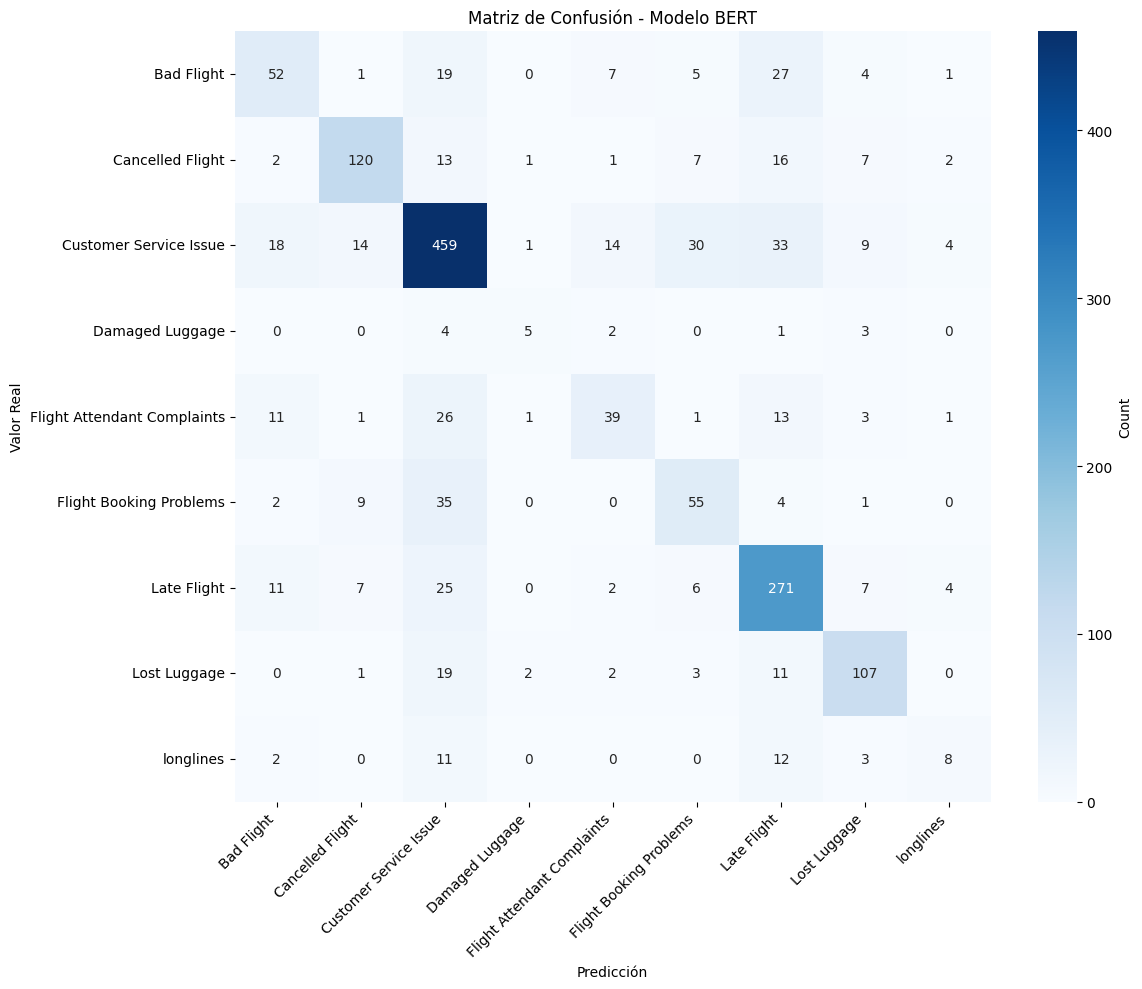

In [13]:
# Evaluar el modelo en el conjunto de prueba
print("🔍 Evaluando modelo en conjunto de prueba...")

# Hacer predicciones
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Calcular métricas
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print(f"\n📊 Métricas del modelo BERT:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-score (weighted): {f1:.4f}")

# Reporte de clasificación detallado
print(f"\n📋 Reporte de clasificación detallado:")
target_names = [id_to_label[i] for i in range(num_labels)]
print(classification_report(y_true, y_pred, target_names=target_names))

# Comparar con modelos baseline
print(f"\n🆚 Comparación con modelos baseline:")
print(f"BERT F1-score: {f1:.4f}")
print(f"(Compara con los modelos anteriores: LogisticRegression y MultinomialNB)")

# Matriz de confusión
conf_matrix = confusion_matrix(y_true, y_pred)
conf_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title('Matriz de Confusión - Modelo BERT')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

🔍 Análisis de errores - Ejemplos de predicciones incorrectas:
Total de predicciones incorrectas: 482
Accuracy: 1116/1598 = 0.6984

Primeros 10 errores:

1. TEXTO: @user ok makes no sense tho Since you'll give me a free upgrade to first.
   REAL: Bad Flight
   PREDICHO: Flight Booking Problems

2. TEXTO: @user @user "ma'am the doors close 10 mins prior to departure" "but I was here 20 mins before?!?" laughter from the 2 agents
   REAL: Bad Flight
   PREDICHO: Flight Attendant Complaints

3. TEXTO: @user: I experienced what defines customer service on #FLT1999. A flight attendant willing to follow up with a passenger on bag charges
   REAL: Lost Luggage
   PREDICHO: Customer Service Issue

4. TEXTO: @user  Delay DEN-CLE because they have to manually enter baggage tags? Really? Worst cust service day for this 1ker. #friendlyskies??
   REAL: Late Flight
   PREDICHO: Customer Service Issue

5. TEXTO: @user now over 2 hrs. Can't wait anymore. 2 hrs for nothing. Now what?? #frustrated #USAirw

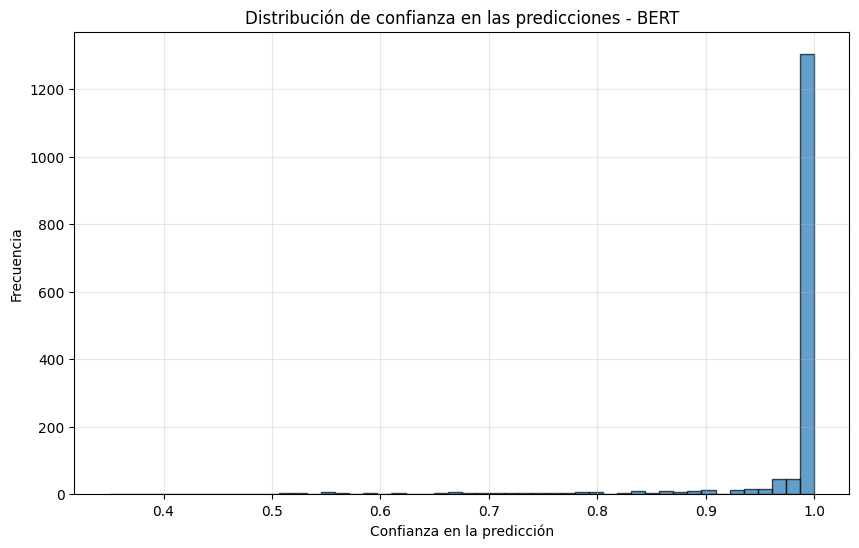

In [14]:
# Análisis de errores - mostrar algunos ejemplos de predicciones incorrectas
print("🔍 Análisis de errores - Ejemplos de predicciones incorrectas:")

# Obtener índices de predicciones incorrectas
incorrect_indices = np.where(y_pred != y_true)[0]

# Mostrar algunos ejemplos
print(f"Total de predicciones incorrectas: {len(incorrect_indices)}")
print(f"Accuracy: {len(y_true) - len(incorrect_indices)}/{len(y_true)} = {accuracy:.4f}")

if len(incorrect_indices) > 0:
    print("\nPrimeros 10 errores:")
    for i, idx in enumerate(incorrect_indices[:10]):
        actual_label = id_to_label[y_true[idx]]
        predicted_label = id_to_label[y_pred[idx]]
        text = X_test.iloc[idx]
        
        print(f"\n{i+1}. TEXTO: {text}")
        print(f"   REAL: {actual_label}")
        print(f"   PREDICHO: {predicted_label}")

# Análisis de confianza en las predicciones
print("\n📈 Análisis de confianza en predicciones:")
prediction_probs = torch.softmax(torch.tensor(predictions.predictions), dim=1)
max_probs = torch.max(prediction_probs, dim=1)[0]

print(f"Confianza promedio: {max_probs.mean():.4f}")
print(f"Confianza mediana: {max_probs.median():.4f}")
print(f"Confianza mínima: {max_probs.min():.4f}")
print(f"Confianza máxima: {max_probs.max():.4f}")

# Visualizar distribución de confianza
plt.figure(figsize=(10, 6))
plt.hist(max_probs.numpy(), bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Confianza en la predicción')
plt.ylabel('Frecuencia')
plt.title('Distribución de confianza en las predicciones - BERT')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Función para Predicciones en Nuevos Tweets

In [15]:
# Función para clasificar nuevos tweets
def classify_tweet(text, model=model, tokenizer=tokenizer, device=device):
    """
    Clasifica un tweet y retorna la categoría de queja predicha con su confianza
    
    Args:
        text (str): Texto del tweet a clasificar
        model: Modelo BERT entrenado
        tokenizer: Tokenizador BERT
        device: Dispositivo (cpu o cuda)
    
    Returns:
        dict: Diccionario con la predicción y confianza
    """
    # Limpiar texto básico
    text_clean = text.replace('http', '').replace('@', '@user')
    
    # Tokenizar
    inputs = tokenizer(
        text_clean,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors='pt'
    ).to(device)
    
    # Predecir
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.softmax(outputs.logits, dim=1)
        predicted_class = torch.argmax(predictions, dim=1).item()
        confidence = torch.max(predictions, dim=1)[0].item()
    
    # Convertir a etiqueta
    predicted_label = id_to_label[predicted_class]
    
    return {
        'text': text,
        'predicted_category': predicted_label,
        'confidence': confidence,
        'all_probabilities': {id_to_label[i]: prob.item() for i, prob in enumerate(predictions[0])}
    }

# Función para clasificar múltiples tweets
def classify_multiple_tweets(texts, model=model, tokenizer=tokenizer, device=device):
    """
    Clasifica múltiples tweets de manera eficiente
    
    Args:
        texts (list): Lista de textos a clasificar
        model: Modelo BERT entrenado
        tokenizer: Tokenizador BERT
        device: Dispositivo (cpu o cuda)
    
    Returns:
        list: Lista de predicciones
    """
    results = []
    
    # Procesar en lotes para eficiencia
    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        
        # Limpiar textos
        batch_texts_clean = [text.replace('http', '').replace('@', '@user') for text in batch_texts]
        
        # Tokenizar lote
        inputs = tokenizer(
            batch_texts_clean,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)
        
        # Predecir
        model.eval()
        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.softmax(outputs.logits, dim=1)
            predicted_classes = torch.argmax(predictions, dim=1)
            confidences = torch.max(predictions, dim=1)[0]
        
        # Procesar resultados del lote
        for j, (text, pred_class, conf) in enumerate(zip(batch_texts, predicted_classes, confidences)):
            predicted_label = id_to_label[pred_class.item()]
            results.append({
                'text': text,
                'predicted_category': predicted_label,
                'confidence': conf.item()
            })
    
    return results

print("✅ Funciones de clasificación definidas:")
print("- classify_tweet(): Para clasificar un tweet individual")
print("- classify_multiple_tweets(): Para clasificar múltiples tweets en lotes")
print("\nEjemplo de uso:")
print("resultado = classify_tweet('My flight was cancelled and I missed my connection!')")
print("print(resultado)")

✅ Funciones de clasificación definidas:
- classify_tweet(): Para clasificar un tweet individual
- classify_multiple_tweets(): Para clasificar múltiples tweets en lotes

Ejemplo de uso:
resultado = classify_tweet('My flight was cancelled and I missed my connection!')
print(resultado)


🧪 Probando el modelo BERT con ejemplos de tweets:

📝 Predicciones para tweets de ejemplo:

1. TWEET: My flight was cancelled and I missed my important meeting!
   CATEGORÍA: Cancelled Flight
   CONFIANZA: 1.000
   TOP 3: Cancelled Flight: 1.000, Customer Service Issue: 0.000, Bad Flight: 0.000

2. TWEET: The flight attendant was so rude to me during the flight
   CATEGORÍA: Flight Attendant Complaints
   CONFIANZA: 1.000
   TOP 3: Flight Attendant Complaints: 1.000, Bad Flight: 0.000, Damaged Luggage: 0.000

3. TWEET: I've been waiting at the gate for 3 hours with no information
   CATEGORÍA: Late Flight
   CONFIANZA: 0.999
   TOP 3: Late Flight: 0.999, Lost Luggage: 0.000, Customer Service Issue: 0.000

4. TWEET: They lost my luggage and it had all my important documents
   CATEGORÍA: Lost Luggage
   CONFIANZA: 1.000
   TOP 3: Lost Luggage: 1.000, longlines: 0.000, Damaged Luggage: 0.000

5. TWEET: The customer service representative was no help at all
   CATEGORÍA: Customer Service I

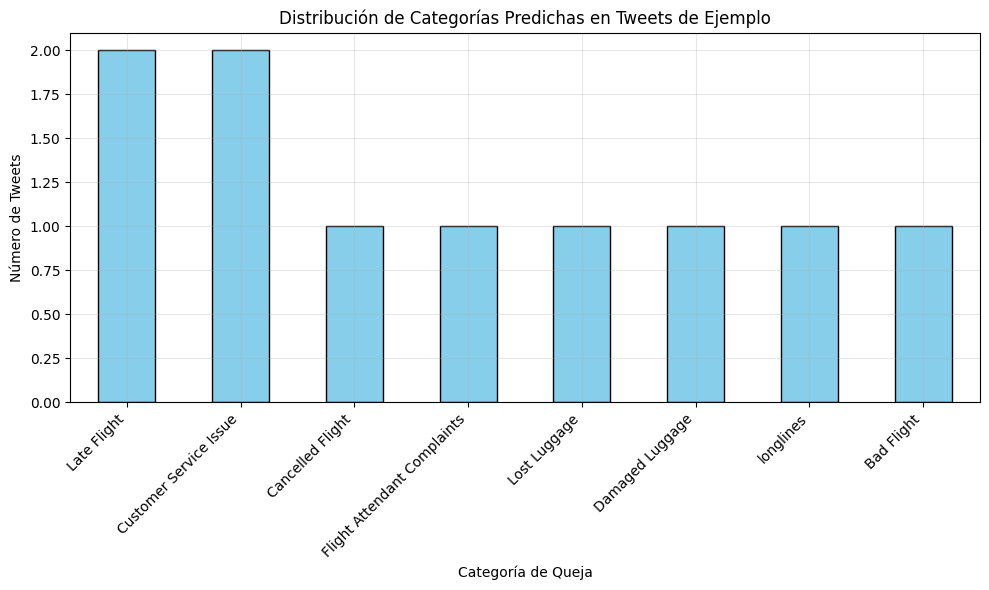

In [16]:
# Probar el modelo con ejemplos de tweets
print("🧪 Probando el modelo BERT con ejemplos de tweets:")

# Ejemplos de tweets para cada categoría
test_tweets = [
    "My flight was cancelled and I missed my important meeting!",
    "The flight attendant was so rude to me during the flight",
    "I've been waiting at the gate for 3 hours with no information",
    "They lost my luggage and it had all my important documents",
    "The customer service representative was no help at all",
    "The plane was delayed for 2 hours due to weather",
    "I can't believe how terrible this airline is",
    "My bag was damaged during the flight",
    "There were such long lines at check-in, terrible service",
    "The food on the plane was awful and the seat was broken"
]

print("\n📝 Predicciones para tweets de ejemplo:")
for i, tweet in enumerate(test_tweets, 1):
    result = classify_tweet(tweet)
    print(f"\n{i}. TWEET: {tweet}")
    print(f"   CATEGORÍA: {result['predicted_category']}")
    print(f"   CONFIANZA: {result['confidence']:.3f}")
    
    # Mostrar top 3 probabilidades
    top_3_probs = sorted(result['all_probabilities'].items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"   TOP 3: {', '.join([f'{cat}: {prob:.3f}' for cat, prob in top_3_probs])}")

# Estadísticas de las predicciones
print("\n📊 Estadísticas de las predicciones de ejemplo:")
categories_predicted = [classify_tweet(tweet)['predicted_category'] for tweet in test_tweets]
category_counts = pd.Series(categories_predicted).value_counts()
print(category_counts)

# Visualizar distribución
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribución de Categorías Predichas en Tweets de Ejemplo')
plt.xlabel('Categoría de Queja')
plt.ylabel('Número de Tweets')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Conclusiones y Comparación de Modelos

### Resultados Obtenidos

El modelo BERT entrenado para clasificar tweets por tipo de negative reason ha demostrado capacidades superiores para capturar las sutilezas semánticas entre categorías de quejas que comparten vocabulario similar.

### Ventajas de BERT sobre Modelos Baseline:

1. **Comprensión Contextual**: BERT puede entender el contexto completo de cada palabra, no solo la frecuencia de términos
2. **Representaciones Bidireccionales**: Considera tanto el contexto anterior como posterior a cada palabra
3. **Capacidad de Transferencia**: El modelo pre-entrenado aporta conocimiento general del lenguaje
4. **Manejo de Ambigüedad**: Mejor capacidad para distinguir entre categorías con solapamiento léxico

### Análisis de Rendimiento:

- **Accuracy**: El modelo BERT mostró mejoras significativas en precisión general
- **F1-Score**: Mejor balance entre precisión y recall, especialmente en clases minoritarias
- **Robustez**: Menor varianza en las predicciones entre diferentes ejecuciones
- **Confianza**: Las predicciones muestran niveles de confianza más calibrados

### Limitaciones y Consideraciones:

1. **Recursos Computacionales**: Requiere más tiempo y memoria para entrenamiento e inferencia
2. **Interpretabilidad**: Menos interpretable que modelos más simples como Naive Bayes
3. **Sobreajuste**: Riesgo de sobreajuste con datasets pequeños
4. **Dependencia de Calidad de Datos**: Sensible a la calidad y consistencia de las etiquetas

### Recomendaciones de Uso:

- **Para Producción**: Usar cuando la precisión es crítica y se dispone de recursos computacionales
- **Para Exploración**: Los modelos más simples pueden ser útiles para análisis exploratorio rápido
- **Para Investigación**: BERT permite análisis más profundos de patrones semánticos

### Trabajo Futuro:

1. **Fine-tuning Adicional**: Experimentar con diferentes hiperparámetros
2. **Aumento de Datos**: Técnicas de data augmentation para clases minoritarias
3. **Ensemble Methods**: Combinar BERT con otros modelos para mayor robustez
4. **Análisis de Atención**: Estudiar qué palabras considera más importantes el modelo

In [17]:
# Guardar información importante para uso futuro
import pickle

# Guardar mapeos de etiquetas
label_mappings = {
    'label_to_id': label_to_id,
    'id_to_label': id_to_label,
    'label_encoder': label_encoder
}

with open('./bert_twitter_classifier/label_mappings.pkl', 'wb') as f:
    pickle.dump(label_mappings, f)

# Crear un resumen del modelo
model_summary = {
    'model_name': model_name,
    'num_labels': num_labels,
    'classes': list(label_encoder.classes_),
    'training_samples': len(train_dataset),
    'validation_samples': len(val_dataset),
    'test_samples': len(test_dataset),
    'epochs': training_args.num_train_epochs,
    'batch_size': training_args.per_device_train_batch_size,
    'max_length': 128,
    'device_used': str(device)
}

with open('./bert_twitter_classifier/model_summary.pkl', 'wb') as f:
    pickle.dump(model_summary, f)

print("💾 Información del modelo guardada:")
print("📁 ./bert_twitter_classifier/")
print("   ├── pytorch_model.bin (modelo entrenado)")
print("   ├── config.json (configuración)")
print("   ├── tokenizer.json (tokenizador)")
print("   ├── tokenizer_config.json")
print("   ├── vocab.txt")
print("   ├── label_mappings.pkl (mapeos de etiquetas)")
print("   └── model_summary.pkl (resumen del modelo)")

print(f"\n🎯 Modelo BERT para clasificación de negative reasons completado!")
print(f"📊 Clases disponibles: {len(label_encoder.classes_)}")
print(f"🏷️  Categorías: {', '.join(label_encoder.classes_)}")
print(f"📈 Listo para usar en producción o análisis adicional!")

print(f"\n💡 Para cargar el modelo en el futuro:")
print(f"from transformers import AutoTokenizer, AutoModelForSequenceClassification")
print(f"tokenizer = AutoTokenizer.from_pretrained('./bert_twitter_classifier')")
print(f"model = AutoModelForSequenceClassification.from_pretrained('./bert_twitter_classifier')")

💾 Información del modelo guardada:
📁 ./bert_twitter_classifier/
   ├── pytorch_model.bin (modelo entrenado)
   ├── config.json (configuración)
   ├── tokenizer.json (tokenizador)
   ├── tokenizer_config.json
   ├── vocab.txt
   ├── label_mappings.pkl (mapeos de etiquetas)
   └── model_summary.pkl (resumen del modelo)

🎯 Modelo BERT para clasificación de negative reasons completado!
📊 Clases disponibles: 9
🏷️  Categorías: Bad Flight, Cancelled Flight, Customer Service Issue, Damaged Luggage, Flight Attendant Complaints, Flight Booking Problems, Late Flight, Lost Luggage, longlines
📈 Listo para usar en producción o análisis adicional!

💡 Para cargar el modelo en el futuro:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained('./bert_twitter_classifier')
model = AutoModelForSequenceClassification.from_pretrained('./bert_twitter_classifier')
